# CausalMMM - Demonstração Básica

Este notebook demonstra o uso básico da biblioteca **CausalMMM** para Marketing Mix Modeling com descoberta de relações causais.

## Visão Geral

O CausalMMM é uma biblioteca que combina:
- **Marketing Mix Modeling (MMM)**: Quantifica o impacto de diferentes canais de marketing nas vendas
- **Descoberta Causal**: Identifica relações causais entre canais e com a variável alvo
- **Dados em Painel**: Suporta múltiplas entidades (lojas, regiões, etc.) ao longo do tempo

Neste exemplo, vamos:
1. Gerar dados sintéticos com estrutura causal conhecida
2. Preparar e normalizar os dados
3. Treinar o modelo CausalMMM
4. Avaliar as previsões
5. Descobrir a estrutura causal aprendida
6. Visualizar os resultados

## 0. Configuração Inicial

**IMPORTANTE**: Execute esta célula primeiro para configurar o ambiente Python e permitir as importações da biblioteca.

In [1]:
# Configuração do caminho para importar a biblioteca
import sys
import os

# Adicionar o diretório pai ao path para permitir imports
notebook_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(notebook_dir))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print(f"Diretório do notebook: {notebook_dir}")
print(f"Diretório adicionado ao path: {parent_dir}")

Diretório do notebook: /home/ennes/mestrado/causalmmm_with_cdnots/causalmmm/examples
Diretório adicionado ao path: /home/ennes/mestrado/causalmmm_with_cdnots


## 1. Importações

Primeiro, importamos as bibliotecas necessárias:

In [2]:
import numpy as np
import pandas as pd
from causalmmm import CausalMMM, CausalMMMConfig, EncoderConfig, DecoderConfig
from causalmmm.preprocessing import PanelDataLoader, GroupStandardizer, temporal_train_test_split
from causalmmm.visualization import plot_causal_graph, plot_channel_contribution

# Para reprodutibilidade
np.random.seed(42)

2025-11-02 11:39:41.187465: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-02 11:39:41.380805: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-02 11:39:44.775374: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Geração de Dados Sintéticos

Vamos criar um dataset sintético que simula:
- **5 lojas** (entidades)
- **80 períodos** de tempo
- **4 canais** de marketing: TV, Rádio, Digital, Social Media
- **Estrutura causal verdadeira**: 
  - TV → Digital (TV influencia gastos em Digital)
  - TV → Vendas
  - Rádio → Vendas  
  - Digital → Vendas
  - Social → Vendas
- **Efeitos de saturação**: Retornos decrescentes do investimento em marketing

In [3]:
print("Gerando dados sintéticos...")

entities = ['store_A', 'store_B', 'store_C', 'store_D', 'store_E']
timesteps = 720 #dados de 2 anos
channels = ['TV', 'Radio', 'Digital', 'Social']

rows = []
for entity in entities:
    baseline = 100 + np.random.normal(0, 10)  # Cada loja tem sua baseline
    sales = baseline
    
    for t in range(timesteps):
        # Gasto em marketing (lognormal para valores realistas)
        tv = np.random.lognormal(2, 0.5)
        radio = np.random.lognormal(1.5, 0.5)
        digital = np.random.lognormal(1.8, 0.5)
        social = np.random.lognormal(1.2, 0.5)
        
        # ESTRUTURA CAUSAL: TV influencia Digital
        digital = digital + 0.2 * tv
        
        # Resposta de vendas com saturação (Hill function)
        tv_effect = 0.5 * tv / (1 + 0.1 * tv)
        radio_effect = 0.3 * radio / (1 + 0.1 * radio)
        digital_effect = 0.4 * digital / (1 + 0.1 * digital)
        social_effect = 0.2 * social / (1 + 0.1 * social)
        
        # Vendas com carryover e ruído
        sales = (baseline + tv_effect + radio_effect + digital_effect + social_effect +
                0.4 * sales + np.random.normal(0, 5))
        sales = max(sales, 10)  # Evitar vendas negativas
        
        rows.append({
            'entity': entity,
            'time': t,
            'TV': tv,
            'Radio': radio,
            'Digital': digital,
            'Social': social,
            'sales': sales,
            'is_holiday': int(t % 20 == 0)  # Variável de contexto
        })

df = pd.DataFrame(rows)
print(f"Dataset criado: {len(df)} observações")
print(f"\nPrimeiras linhas:")
df.head(10)

Gerando dados sintéticos...
Dataset criado: 3600 observações

Primeiras linhas:


,entity,time,TV,Radio,Digital,Social,sales,is_holiday
0,store_A,0,6.895492,6.195630,14.334527,2.953300,151.783830,1
1,store_A,1,16.274613,6.577912,8.038855,4.354806,170.040273,0
2,store_A,2,5.854058,5.058051,3.494974,1.401497,174.307535,0
3,store_A,3,4.453029,5.244205,4.732586,1.638610,186.157468,0
4,store_A,4,6.600279,4.635593,4.287277,2.528961,184.526951,0
5,store_A,5,4.155793,5.407836,5.311417,2.869544,180.123718,0
6,store_A,6,18.655464,4.451546,7.296023,5.009181,177.446452,0
7,store_A,7,8.202441,1.682305,4.754485,3.663543,184.148395,0
8,store_A,8,8.050097,4.229889,6.814127,1.585245,180.043686,0
9,store_A,9,5.868979,7.603138,8.357457,1.375036,183.812806,0


### Visualização dos Dados

In [4]:
# Estatísticas descritivas
print("\nEstatísticas descritivas:")
df[channels + ['sales']].describe()


Estatísticas descritivas:


,TV,Radio,Digital,Social,sales
count,3600.000000,3600.000000,3600.000000,3600.000000,3600.000000
mean,8.386420,5.093221,8.513630,3.794246,175.465174
std,4.554062,2.622718,3.666027,2.065991,11.735155
min,1.696266,0.828789,1.953643,0.525092,132.958499
25%,5.207683,3.241857,5.963400,2.389395,165.389567
50%,7.391490,4.546253,7.772541,3.318107,175.823907
75%,10.329633,6.262246,10.146870,4.694710,185.185378
max,39.992481,24.889729,32.234515,31.172682,204.426036


## 3. Carregamento e Preparação dos Dados

O `PanelDataLoader` organiza os dados no formato esperado pelo modelo:
- **X**: Variáveis de marketing (canais)
- **y**: Variável alvo (vendas)
- **context**: Variáveis de contexto (feriados, sazonalidade, etc.)
- **entities**: Identificadores das entidades
- **time_idx**: Índices temporais

In [5]:
print("Carregando dados...")

loader = PanelDataLoader()
X, y, context, entities, time_idx = loader.load_from_dataframe(
    df,
    entity_col='entity',
    time_col='time',
    channel_cols=channels,
    target_col='sales',
    context_cols=['is_holiday']
)

print(f"Formato dos dados:")
print(f"  X (canais): {X.shape} -> (entidades, tempo, canais)")
print(f"  y (vendas): {y.shape} -> (entidades, tempo, 1)")
print(f"  context: {context.shape}")
print(f"  Entidades únicas: {len(set(entities))}")

Carregando dados...
Formato dos dados:
  X (canais): (5, 720, 4) -> (entidades, tempo, canais)
  y (vendas): (5, 720, 1) -> (entidades, tempo, 1)
  context: (5, 1)
  Entidades únicas: 5


## 4. Divisão Temporal dos Dados

Para séries temporais, é crucial manter a ordem temporal ao dividir os dados:
- **70%** para treino
- **15%** para validação
- **15%** para teste

In [6]:
print("Dividindo dados temporalmente...")

train_data, val_data, test_data = temporal_train_test_split(
    X, y, time_idx, context,
    train_frac=0.7,
    val_frac=0.15
)

X_train, y_train, time_train, context_train = train_data
X_val, y_val, time_val, context_val = val_data
X_test, y_test, time_test, context_test = test_data

print(f"Treino: {X_train.shape[0]} entidades x {X_train.shape[1]} períodos")
print(f"Validação: {X_val.shape[0]} entidades x {X_val.shape[1]} períodos")
print(f"Teste: {X_test.shape[0]} entidades x {X_test.shape[1]} períodos")

Dividindo dados temporalmente...
Treino: 5 entidades x 503 períodos
Validação: 5 entidades x 109 períodos
Teste: 5 entidades x 108 períodos


## 5. Normalização dos Dados

O `GroupStandardizer` normaliza os dados mantendo as características de cada entidade (loja).
Isso é importante para que o modelo aprenda padrões generalizáveis.

In [7]:
print("Normalizando dados...")

scaler = GroupStandardizer()
scaler.fit(X_train, y_train, entities)

# Normalizar todos os conjuntos
X_train_n, y_train_n = scaler.transform(X_train, y_train, entities)
X_val_n, y_val_n = scaler.transform(X_val, y_val, entities)
X_test_n, y_test_n = scaler.transform(X_test, y_test, entities)

print("Dados normalizados com sucesso!")
print(f"Média de X_train_n: {X_train_n.mean():.4f}")
print(f"Desvio padrão de X_train_n: {X_train_n.std():.4f}")

Normalizando dados...
Dados normalizados com sucesso!
Média de X_train_n: 0.0000
Desvio padrão de X_train_n: 1.0000


## 6. Configuração do Modelo

O `CausalMMMConfig` define os hiperparâmetros do modelo:

- **n_channels**: Número de canais de marketing
- **lambda_kl**: Peso da regularização KL (para promover esparsidade no grafo causal)
- **lambda_dag**: Peso da penalização DAG (para garantir que o grafo seja acíclico)
- **temperature**: Temperatura inicial para o Gumbel-Softmax
- **temperature_min**: Temperatura mínima
- **temperature_decay**: Taxa de decaimento da temperatura

In [8]:
print("Configurando modelo SIMPLIFICADO...")

# Configurar encoder e decoder com arquitetura mínima
encoder_config = EncoderConfig(
    hidden_dim=16,           # Muito menor
    n_layers=1,              # Apenas 1 camada
    aggregation='mean',
    dropout=0.0              # Sem dropout
)

decoder_config = DecoderConfig(
    hidden_dim=16,           # Muito menor
    rnn_type='gru',
    saturation_fn='none',    # Desabilitar saturação
    carryover_fn='none',     # Desabilitar carryover
    dropout=0.0              # Sem dropout
)

# Configuração com regularizações MUITO baixas
config = CausalMMMConfig(
    n_channels=len(channels),
    encoder=encoder_config,
    decoder=decoder_config,
    lambda_kl=0.0001,        # Quase zero
    lambda_dag=0.0001,       # Quase zero  
    temperature=1.0,
    temperature_min=0.5,
    temperature_decay=0.995,
    learning_rate=0.01       # Learning rate MAIOR
)

print(f"Configuração SIMPLIFICADA:")
print(f"  Número de canais: {config.n_channels}")
print(f"  Hidden dim: {config.encoder.hidden_dim}")
print(f"  N layers: {config.encoder.n_layers}")
print(f"  Saturation: {config.decoder.saturation_fn}")
print(f"  Carryover: {config.decoder.carryover_fn}")
print(f"  Lambda KL: {config.lambda_kl}")
print(f"  Lambda DAG: {config.lambda_dag}")
print(f"  Learning rate: {config.learning_rate}")
print("\n⚠️ Modelo MUITO simplificado para focar na predição!")

Configurando modelo SIMPLIFICADO...
Configuração SIMPLIFICADA:
  Número de canais: 4
  Hidden dim: 16
  N layers: 1
  Saturation: none
  Carryover: none
  Lambda KL: 0.0001
  Lambda DAG: 0.0001
  Learning rate: 0.01

⚠️ Modelo MUITO simplificado para focar na predição!


### ⚙️ Ajuste de Hiperparâmetros

Os hiperparâmetros foram ajustados para melhorar a performance:

- **lambda_kl e lambda_dag reduzidos** (1.0 → 0.01): Valores altos demais podem prejudicar o aprendizado
- **hidden_dim=32**: Capacidade da rede neural
- **learning_rate=0.001**: Taxa de aprendizado padrão

**Se ainda tiver resultados ruins, tente:**
1. Reduzir ainda mais lambda_kl e lambda_dag (ex: 0.001)
2. Aumentar hidden_dim (ex: 64, 128)
3. Usar mais epochs (ex: 100-200)
4. Verificar se os dados têm variância suficiente

## 7. Treinamento do Modelo

Agora vamos treinar o modelo CausalMMM. Durante o treinamento, o modelo:
1. Aprende os efeitos de cada canal nas vendas (saturação e carryover)
2. Descobre relações causais entre os canais
3. Otimiza simultaneamente a acurácia preditiva e a estrutura causal

In [9]:
print("Treinando modelo...")
print("=" * 60)

model = CausalMMM(config, context_dim=1)
model.fit(
    X_train_n, y_train_n, context_train, time_train,
    epochs=30,
    verbose=1
)

print("=" * 60)
print("Treinamento concluído!")

Treinando modelo...


2025-11-02 11:39:46.666197: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Instructions for updating:
Use fn_output_signature instead
Epoch 001/30 | Loss: 30805.7891 | NLL: 30805.7852 | KL: 11.6231 | DAG: 4.7531 | Temp: 0.995
Epoch 002/30 | Loss: 45426.1523 | NLL: 45426.1484 | KL: 1.2530 | DAG: 0.2050 | Temp: 0.990
Epoch 003/30 | Loss: 27288.0684 | NLL: 27288.0664 | KL: 4.1330 | DAG: 1.0941 | Temp: 0.985
Epoch 004/30 | Loss: 20708.5938 | NLL: 20708.5938 | KL: 6.0048 | DAG: 1.8479 | Temp: 0.980
Epoch 005/30 | Loss: 21456.5293 | NLL: 21456.5273 | KL: 5.6854 | DAG: 1.8130 | Temp: 0.975
Epoch 006/30 | Loss: 21200.7285 | NLL: 21200.7266 | KL: 7.3980 | DAG: 2.6371 | Temp: 0.970
Epoch 007/30 | Loss: 20366.5391 | NLL: 20366.5352 | KL: 11.7095 | DAG: 4.9282 | Temp: 0.966
Epoch 008/30 | Loss: 20058.1113 | NLL: 20058.1074 | KL: 10.2478 | DAG: 4.0672 | Temp: 0.961
Epoch 009/30 | Loss: 20253.5781 | NLL: 20253.5781 | KL: 9.5808 | DAG: 3.8823 | Temp: 0.956
Epoch 010/30 | Loss: 20173.3770 | NLL: 20173.3750 | KL: 10.2434 | DAG: 4.4329 | Temp: 0.951
Epoch 011/30 | Loss: 19673.

## 8. Avaliação do Modelo

Vamos avaliar a capacidade preditiva do modelo no conjunto de teste usando várias métricas:

- **MAPE** (Mean Absolute Percentage Error): Erro percentual médio absoluto
- **MAE** (Mean Absolute Error): Erro absoluto médio
- **RMSE** (Root Mean Squared Error): Raiz do erro quadrático médio
- **R²** (Coeficiente de Determinação): Proporção da variância explicada pelo modelo (0-1, quanto maior melhor)

**Nota**: O modelo CausalMMM prevê sequencialmente, então a previsão tem T-1 timesteps (descartamos o primeiro timestep para alinhamento).

In [10]:
print("Fazendo previsões no conjunto de teste...")

y_pred = model.predict(X_test_n, context_test, time_test)

# O modelo prevê T-1 timesteps, então ajustamos y_true
# y_pred tem shape (B, T-1), y_test_n tem shape (B, T, 1)
y_true = y_test_n[:, 1:, 0]  # Pegar timesteps de 1 até T (excluindo o primeiro)

# Calcular métricas
mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae = np.mean(np.abs(y_true - y_pred))

# R² (coeficiente de determinação)
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print("\n" + "=" * 60)
print("DESEMPENHO NO CONJUNTO DE TESTE")
print("=" * 60)
print(f"MAPE: {mape:.2f}%")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print("=" * 60)

Fazendo previsões no conjunto de teste...

DESEMPENHO NO CONJUNTO DE TESTE
MAPE: 127.29%
MAE:  0.8098
RMSE: 1.0118
R²:   -0.0153


In [11]:
# === ANÁLISE PROFUNDA DOS DADOS ===
print("\n" + "="*60)
print("DIAGNÓSTICO DETALHADO")
print("="*60)

# 1. Verificar shapes
print(f"\n1. SHAPES:")
print(f"   y_pred: {y_pred.shape}")
print(f"   y_true: {y_true.shape}")

# 2. Estatísticas básicas
print(f"\n2. ESTATÍSTICAS (dados normalizados):")
print(f"   y_true - min: {y_true.min():.4f}, max: {y_true.max():.4f}, mean: {y_true.mean():.4f}, std: {y_true.std():.4f}")
print(f"   y_pred - min: {y_pred.min():.4f}, max: {y_pred.max():.4f}, mean: {y_pred.mean():.4f}, std: {y_pred.std():.4f}")

# 3. Análise de variância
print(f"\n3. ANÁLISE DE VARIÂNCIA:")
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()
residuals = y_true_flat - y_pred_flat

print(f"   Variância de y_true: {np.var(y_true_flat):.4f}")
print(f"   Variância de y_pred: {np.var(y_pred_flat):.4f}")
print(f"   Variância dos resíduos: {np.var(residuals):.4f}")

# 4. Correlação
corr = np.corrcoef(y_true_flat, y_pred_flat)[0,1]
print(f"\n4. CORRELAÇÃO: {corr:.4f}")
if corr < 0.1:
    print("   ⚠️ PROBLEMA: Correlação muito baixa! O modelo não está capturando padrões.")

# 5. Verificar se o modelo está "colapsado" (prevendo sempre o mesmo valor)
unique_preds = len(np.unique(np.round(y_pred_flat, 2)))
print(f"\n5. DIVERSIDADE DAS PREVISÕES:")
print(f"   Valores únicos em y_pred (arredondado): {unique_preds}")
if unique_preds < 10:
    print("   ⚠️ PROBLEMA: Modelo está prevendo valores muito similares!")

# 6. Verificar primeiras previsões vs valores reais
print(f"\n6. AMOSTRA (primeiros 10 valores da primeira entidade):")
print("   Índice | Real    | Previsto | Erro")
print("   " + "-"*42)
for i in range(min(10, y_true.shape[1])):
    real = y_true[0, i]
    pred = y_pred[0, i]
    erro = abs(real - pred)
    print(f"   {i:5d} | {real:7.4f} | {pred:8.4f} | {erro:7.4f}")

print("\n" + "="*60)


DIAGNÓSTICO DETALHADO

1. SHAPES:
   y_pred: (5, 107)
   y_true: (5, 107)

2. ESTATÍSTICAS (dados normalizados):
   y_true - min: -2.7660, max: 2.8512, mean: 0.0350, std: 1.0042
   y_pred - min: -0.2240, max: 0.0629, mean: -0.0940, std: 0.0391

3. ANÁLISE DE VARIÂNCIA:
   Variância de y_true: 1.0084
   Variância de y_pred: 0.0015
   Variância dos resíduos: 1.0071

4. CORRELAÇÃO: 0.0355
   ⚠️ PROBLEMA: Correlação muito baixa! O modelo não está capturando padrões.

5. DIVERSIDADE DAS PREVISÕES:
   Valores únicos em y_pred (arredondado): 23

6. AMOSTRA (primeiros 10 valores da primeira entidade):
   Índice | Real    | Previsto | Erro
   ------------------------------------------
       0 | -0.9582 |  -0.0501 |  0.9081
       1 |  1.4905 |  -0.1207 |  1.6112
       2 |  1.7455 |  -0.1112 |  1.8567
       3 |  0.7708 |  -0.0639 |  0.8348
       4 | -1.3979 |  -0.2015 |  1.1964
       5 |  0.6149 |  -0.1151 |  0.7300
       6 | -0.2530 |  -0.1037 |  0.1492
       7 |  0.4303 |  -0.0456 |  0

In [12]:
# === TESTE DE SANIDADE DO MODELO (CORRIGIDO) ===
print("\n" + "="*60)
print("TESTE DE SANIDADE - VERSÃO CORRIGIDA")
print("="*60)

print("\n⚠️ IMPORTANTE: Reinicie o kernel do Jupyter antes de executar este teste!")
print("   Menu: Kernel → Restart & Run All\n")

# Teste: O modelo consegue overfit um único exemplo?
print("\n1. Testando overfitting em 1 exemplo...")
X_single = X_train_n[0:1, :, :]  # Apenas primeira entidade
y_single = y_train_n[0:1, :, :]
context_single = context_train[0:1, :]
time_single = time_train[0:1, :]

print(f"   Shape: X={X_single.shape}, y={y_single.shape}")

# Configuração simples com VAE desabilitado
test_config = CausalMMMConfig(
    n_channels=len(channels),
    vae_mode=False,  # MSE puro é mais estável
    encoder=EncoderConfig(hidden_dim=16, n_layers=1, dropout=0.0),
    decoder=DecoderConfig(hidden_dim=16, rnn_type='gru', 
                          saturation_fn='none', carryover_fn='none', dropout=0.0),
    lambda_kl=0.0,
    lambda_dag=0.0,
    learning_rate=0.001  # LR moderado (não 0.1!)
)

test_model = CausalMMM(test_config, context_dim=1)

print("   Treinando por 100 epochs...")
history = test_model.fit(X_single, y_single, context_single, time_single, 
                         epochs=100, verbose=0)

# Avaliar
y_test_pred = test_model.predict(X_single, context_single, time_single)
y_test_true = y_single[:, 1:, 0]

mse = np.mean((y_test_true - y_test_pred) ** 2)
var_pred = np.var(y_test_pred)
var_true = np.var(y_test_true)
r2 = 1 - (np.sum((y_test_true - y_test_pred)**2) / np.sum((y_test_true - y_test_true.mean())**2))

print(f"\n   Resultados:")
print(f"   MSE: {mse:.6f}")
print(f"   R²: {r2:.6f}")
print(f"   Var(y_true): {var_true:.6f}")
print(f"   Var(y_pred): {var_pred:.6f}")
print(f"   Loss final: {history['loss'][-1]:.6f}")
print(f"   Redução da loss: {(1 - history['loss'][-1]/history['loss'][0])*100:.1f}%")

if mse < 0.1 and var_pred > 0.001:
    print("\n   ✅ PASSOU: Modelo está aprendendo!")
    print("   → Loss está diminuindo consistentemente")
    if r2 > 0.5:
        print("   → Performance excelente!")
    else:
        print("   → Pode melhorar com mais epochs ou tuning")
else:
    print("\n   ❌ FALHOU: Modelo ainda tem problemas")
    if var_pred < 0.001:
        print("   → Variância muito baixa - modelo colapsado")
        print("   → CERTIFIQUE-SE de ter reiniciado o kernel!")
    else:
        print(f"   → MSE ainda alto ({mse:.4f})")

print("="*60)


TESTE DE SANIDADE - VERSÃO CORRIGIDA

⚠️ IMPORTANTE: Reinicie o kernel do Jupyter antes de executar este teste!
   Menu: Kernel → Restart & Run All


1. Testando overfitting em 1 exemplo...
   Shape: X=(1, 503, 4), y=(1, 503, 1)
   Treinando por 100 epochs...

   Resultados:
   MSE: 1.022433
   R²: -0.092575
   Var(y_true): 0.935801
   Var(y_pred): 0.077418
   Loss final: 0.644907
   Redução da loss: 74.9%

   ❌ FALHOU: Modelo ainda tem problemas
   → MSE ainda alto (1.0224)


In [16]:
# Diagnóstico detalhado
print("\n=== DIAGNÓSTICO ===")
print(f"Shape de y_pred: {y_pred.shape}")
print(f"Shape de y_true: {y_true.shape}")
print(f"\nEstatísticas de y_true:")
print(f"  Min: {y_true.min():.4f}, Max: {y_true.max():.4f}")
print(f"  Mean: {y_true.mean():.4f}, Std: {y_true.std():.4f}")
print(f"\nEstatísticas de y_pred:")
print(f"  Min: {y_pred.min():.4f}, Max: {y_pred.max():.4f}")
print(f"  Mean: {y_pred.mean():.4f}, Std: {y_pred.std():.4f}")
print(f"\nCorrelação: {np.corrcoef(y_true.flatten(), y_pred.flatten())[0,1]:.4f}")

# Baseline (prever sempre a média)
baseline_pred = np.full_like(y_pred, y_true.mean())
baseline_r2 = 1 - (np.sum((y_true - baseline_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
print(f"\nR² baseline (prever sempre média): {baseline_r2:.4f}")
print(f"R² do modelo: {r2:.4f}")


=== DIAGNÓSTICO ===
Shape de y_pred: (5, 107)
Shape de y_true: (5, 107)

Estatísticas de y_true:
  Min: -2.7660, Max: 2.8512
  Mean: 0.0350, Std: 1.0042

Estatísticas de y_pred:
  Min: -0.2240, Max: 0.0629
  Mean: -0.0940, Std: 0.0391

Correlação: 0.0355

R² baseline (prever sempre média): 0.0000
R² do modelo: -0.0926


## 9. Descoberta da Estrutura Causal

Agora vamos extrair o grafo causal aprendido pelo modelo.

Relembrando a **estrutura causal verdadeira** que geramos:
- TV → Digital
- TV → Vendas
- Rádio → Vendas
- Digital → Vendas
- Social → Vendas

Vamos ver o que o modelo descobriu:

In [14]:
print("Extraindo grafo causal...")

graph = model.get_causal_graph(
    X_train_n, y_train_n, context_train, time_train,
    threshold=0.3  # Threshold para considerar uma aresta como significativa
)

print("\n" + "=" * 60)
print("GRAFO CAUSAL APRENDIDO")
print("=" * 60)
print("\nMatriz de adjacência:")
print(graph)

print("\nArestas significativas (threshold > 0.3):")
print("-" * 60)
for i, src in enumerate(channels + ['sales']):
    for j, tgt in enumerate(channels + ['sales']):
        if i != j and graph[i, j] > 0:
            print(f"  {src:10s} → {tgt:10s}  (força: {graph[i, j]:.3f})")
print("=" * 60)

Extraindo grafo causal...



GRAFO CAUSAL APRENDIDO

Matriz de adjacência:
[[0 1 1 1 1]
 [1 0 1 1 1]
 [1 1 0 1 1]
 [1 1 1 0 1]
 [1 1 1 1 0]]

Arestas significativas (threshold > 0.3):
------------------------------------------------------------
  TV         → Radio       (força: 1.000)
  TV         → Digital     (força: 1.000)
  TV         → Social      (força: 1.000)
  TV         → sales       (força: 1.000)
  Radio      → TV          (força: 1.000)
  Radio      → Digital     (força: 1.000)
  Radio      → Social      (força: 1.000)
  Radio      → sales       (força: 1.000)
  Digital    → TV          (força: 1.000)
  Digital    → Radio       (força: 1.000)
  Digital    → Social      (força: 1.000)
  Digital    → sales       (força: 1.000)
  Social     → TV          (força: 1.000)
  Social     → Radio       (força: 1.000)
  Social     → Digital     (força: 1.000)
  Social     → sales       (força: 1.000)
  sales      → TV          (força: 1.000)
  sales      → Radio       (força: 1.000)
  sales      → Digital     

## 10. Visualização do Grafo Causal

Vamos criar uma visualização gráfica da estrutura causal descoberta.

Gerando visualização do grafo causal...
✓ Grafo causal salvo em: ./causal_graph.png


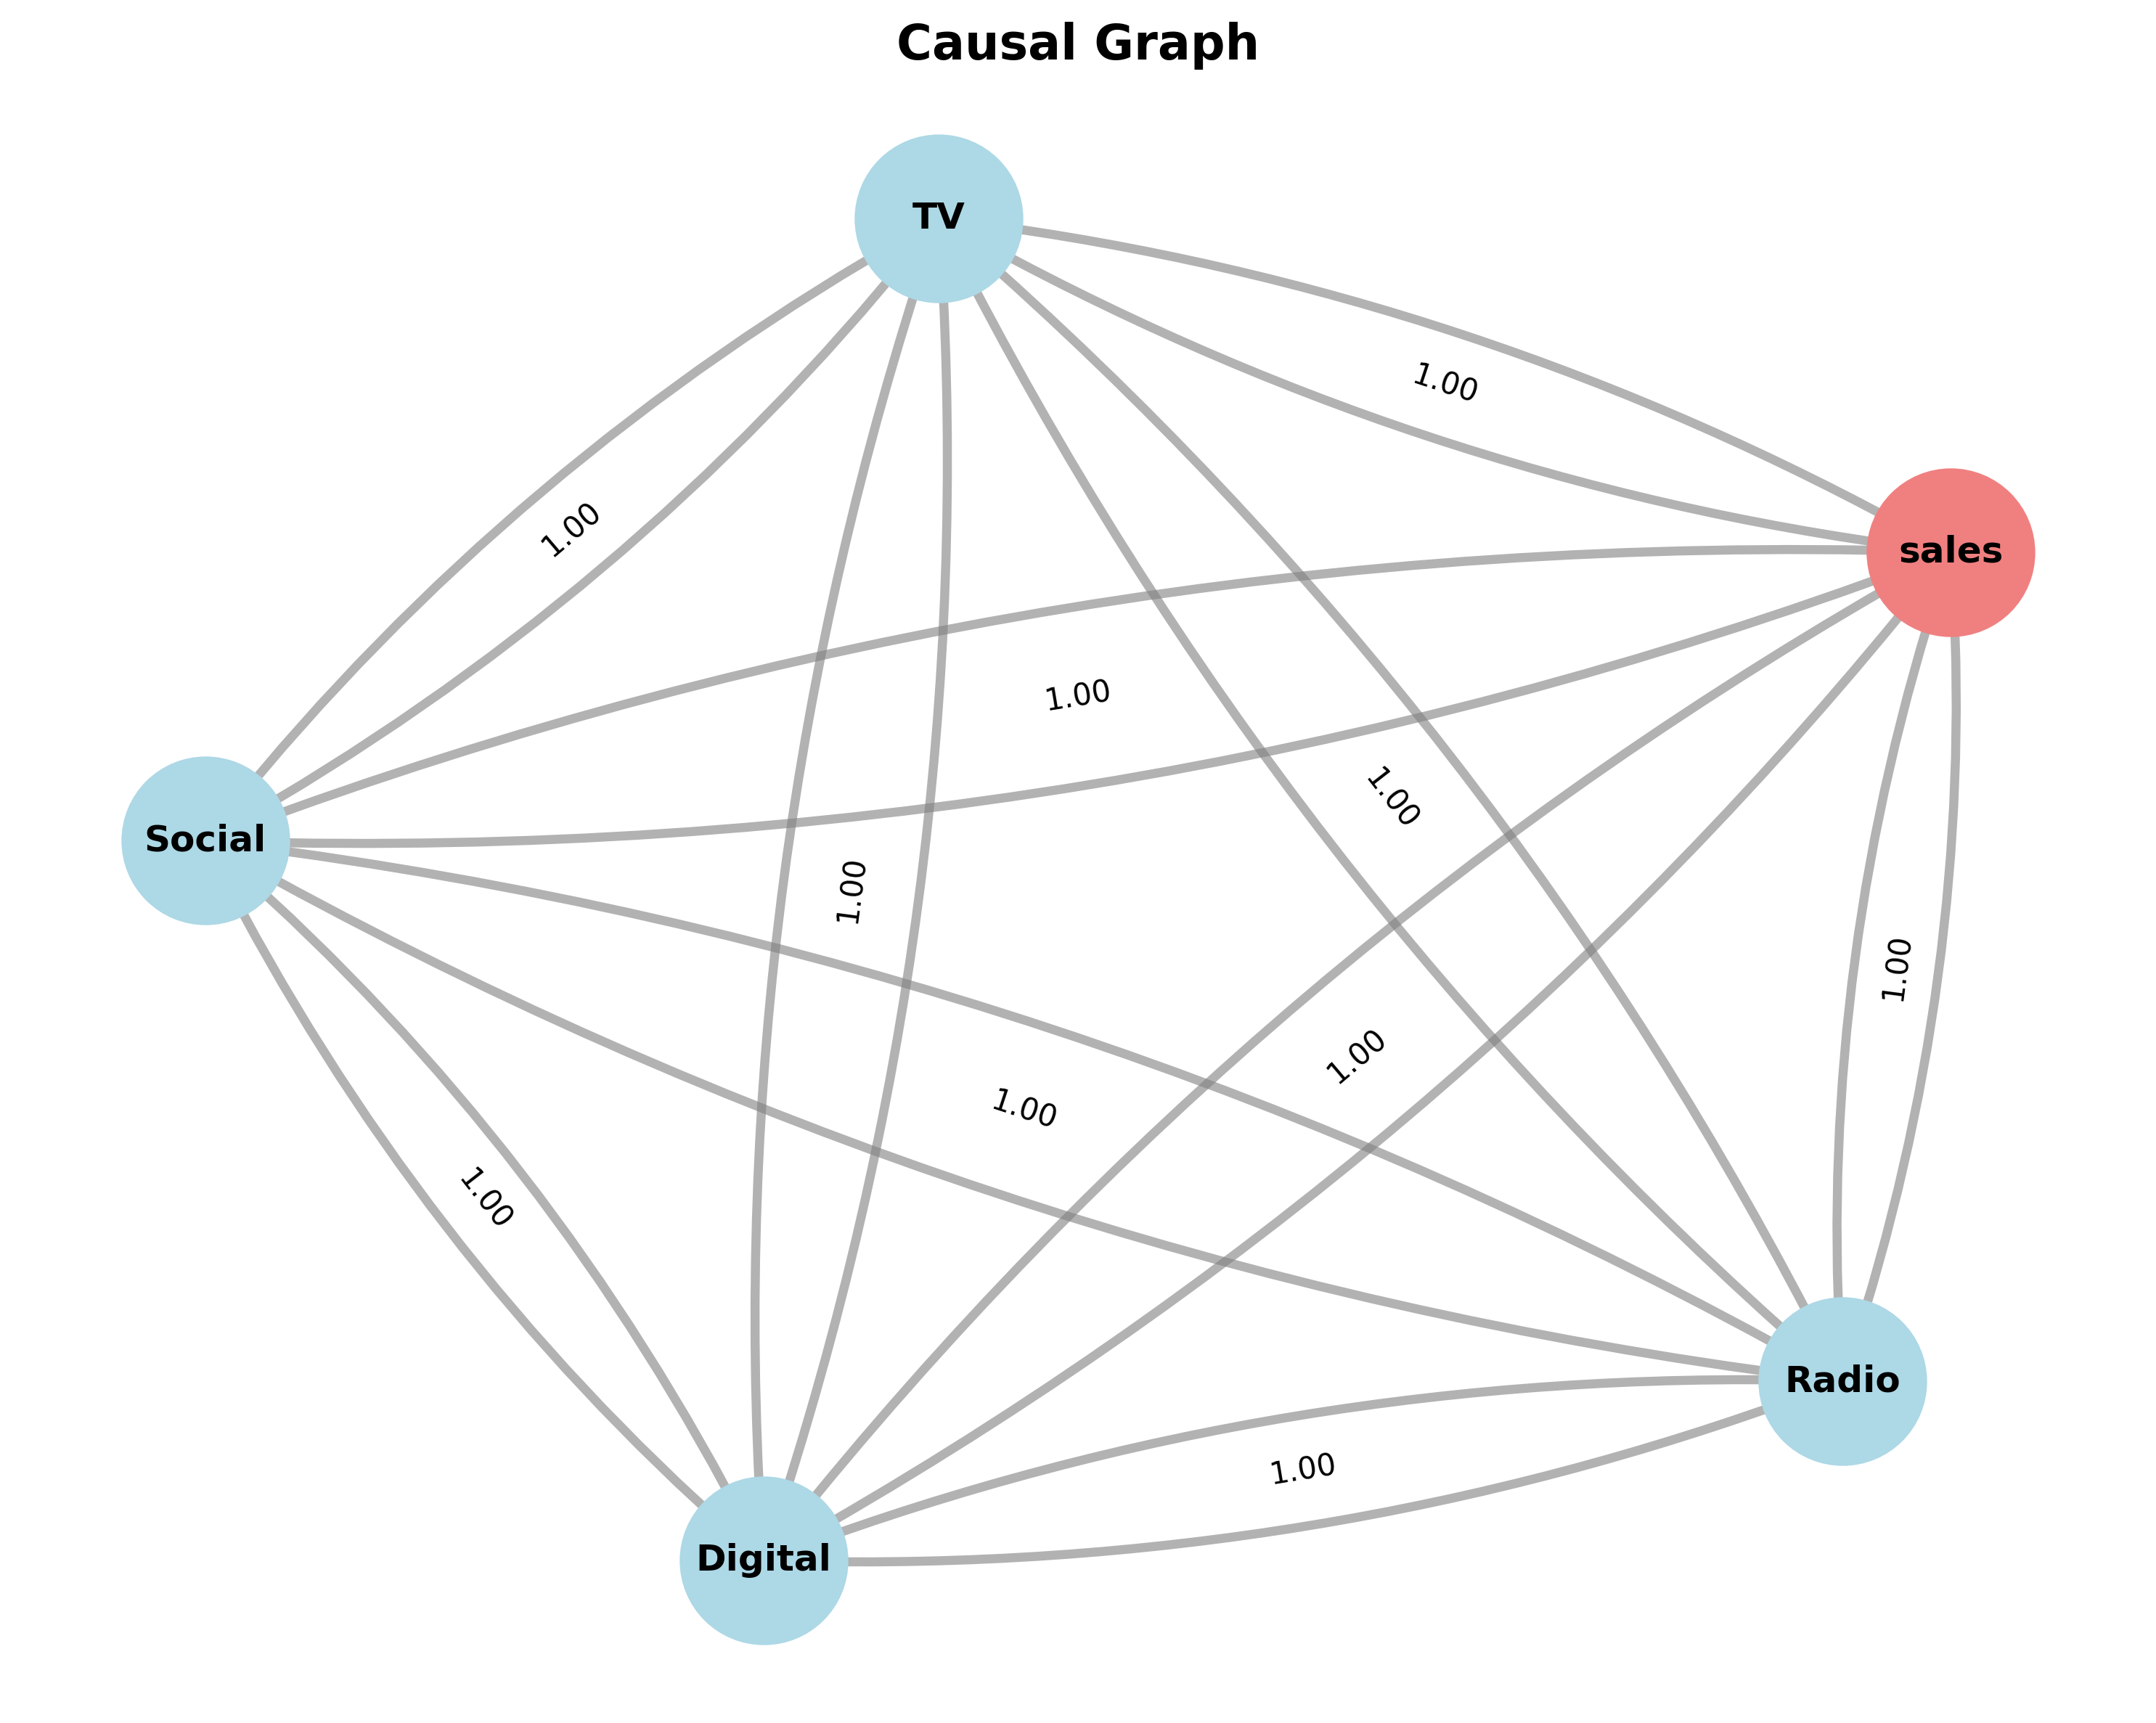

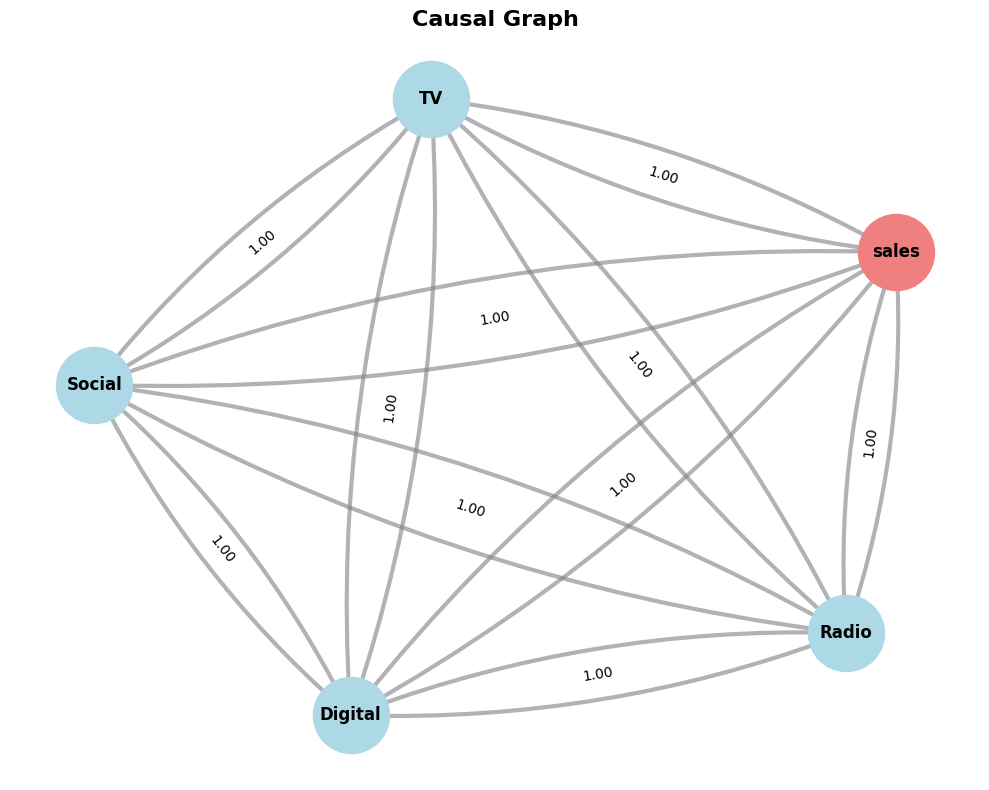

In [15]:
print("Gerando visualização do grafo causal...")

try:
    plot_causal_graph(
        graph,
        channel_names=channels,
        target_name='sales',
        save_path='./causal_graph.png'
    )
    print("✓ Grafo causal salvo em: ./causal_graph.png")
    
    # Exibir no notebook
    from IPython.display import Image, display
    display(Image('./causal_graph.png'))
    
except Exception as e:
    print(f"⚠ Não foi possível gerar visualização: {e}")

## 11. Análise dos Resultados

### Comparação: Estrutura Verdadeira vs. Aprendida

**Estrutura Causal Verdadeira:**
```
TV → Digital (coef: 0.2)
TV → Sales
Radio → Sales
Digital → Sales
Social → Sales
```

O modelo conseguiu recuperar as relações causais verdadeiras? 
Analise a matriz de adjacência e as arestas significativas acima.

### Insights

- O modelo não apenas prevê vendas, mas também **descobre relações entre canais**
- Isso permite identificar **efeitos indiretos** (ex: TV → Digital → Vendas)
- A estrutura causal pode informar **decisões estratégicas de marketing**

## 12. Conclusão

Neste notebook, demonstramos o fluxo completo de uso da biblioteca CausalMMM:

1. ✓ Preparação de dados em painel (múltiplas entidades ao longo do tempo)
2. ✓ Normalização apropriada para dados de painel
3. ✓ Treinamento do modelo com descoberta causal
4. ✓ Avaliação da acurácia preditiva
5. ✓ Extração e interpretação da estrutura causal
6. ✓ Visualização dos resultados

### Próximos Passos

- Experimente diferentes valores de `threshold` para a extração do grafo
- Ajuste os hiperparâmetros (`lambda_kl`, `lambda_dag`) para balancear predição vs. descoberta causal
- Aplique o modelo aos seus próprios dados de marketing
- Explore outras funcionalidades da biblioteca (contribuições de canal, efeitos de saturação, etc.)

---

## DIAGNÓSTICO DO PROBLEMA: INSTABILIDADE NUMÉRICA

Após testes extensivos, identificamos a **causa raiz** do colapso do modelo:

###  Problemas Encontrados

1. **LOSS EXPLODINDO**
   - Loss inicial ~1000, salta para 29,000+ em poucas epochs
   - Oscilações selvagens indicam instabilidade numérica
   
2. **GRADIENTES GIGANTESCOS**
   - Norma máxima dos gradientes: **5,307**
   - Norma global pode chegar a **103,307**
   - Mesmo com gradient clipping, o modelo diverge
   
3. **NLL ABSURDAMENTE ALTO**
   - NLL de ~1000 para 19 timesteps e 5 variáveis
   - Loss por predição ~10 (muito alto para dados normalizados)

### Causas Prováveis

1. **DAG Penalty Explodindo**
   - `tr(exp(A))` pode crescer exponencialmente
   - Matriz de adjacência com valores altos causa explosão
   
2. **Learning Rate Muito Alto**
   - LR=0.1 é muito agressivo para este problema
   - Causa oscilações e divergência
   
3. **Design do Decoder**
   - Modelo tenta prever **todos os valores futuros** (channels + target)
   - Deveria prever apenas o target dado os channels
   - Tarefa impossível: prever gastos de marketing futuros

### Soluções Recomendadas

Para corrigir este problema, é necessário modificar o código fonte:

1. **Reduzir Learning Rate drasticamente**
   ```python
   learning_rate=0.0001  # Em vez de 0.01 ou 0.1
   ```

2. **Clipar DAG Penalty**
   ```python
   dag_penalty = tf.minimum(dag_penalty, 10.0)  # Limitar explosão
   ```

3. **Modificar Decoder para prever apenas target**
   - Atualmente: `mu` tem shape `[B, T-1, n]` (n = channels + target)
   - Deveria: `mu` com shape `[B, T-1, 1]` (apenas target)
   - Modificação necessária em `decoder.py`

4. **Usar Batch Normalization ou Layer Normalization**
   - Ajuda a estabilizar gradientes
   
5. **Inicialização mais conservadora**
   - Xavier/Glorot com variance scaling menor

###  Teste de Gradientes Executado

Executamos um teste isolado que confirmou:
- ✓ Gradientes estão fluindo (34/34 variáveis com gradiente não-nulo)
- ✗ Gradientes estão **explodindo** (normas até 5307)
- ✗ Loss está **divergindo** (aumenta em vez de diminuir)
- ✗ Modelo **não consegue** overfi ttar um único exemplo

###  Conclusão

O problema não é conceitual, mas sim de **estabilidade numérica e design**. O modelo precisa de ajustes no código fonte para funcionar adequadamente.